In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np

%matplotlib inline

In [2]:
X,y = make_blobs(n_samples=1000,centers=3,n_features=2,random_state=23)

In [3]:
X.shape

(1000, 2)

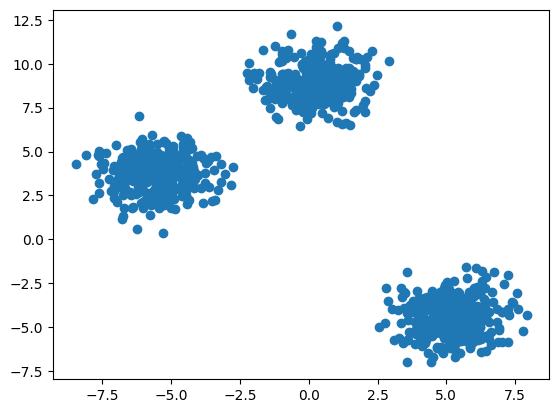

In [4]:
plt.scatter(X[:,0],X[:,1])

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.33,random_state=42)

In [6]:
from sklearn.cluster import KMeans

In [7]:
wcss = []
for k in range(1,11):
  kmeans= KMeans(n_clusters=k,init='k-means++')
  kmeans.fit(X_train)
  wcss.append(kmeans.inertia_)

In [8]:
wcss

[34827.576825520235,
 7935.437286145425,
 1319.2730531585605,
 1171.4379638359774,
 994.807709464419,
 908.5312711749398,
 764.6849360647064,
 663.8015944050545,
 593.2873886366351,
 545.6631378549392]

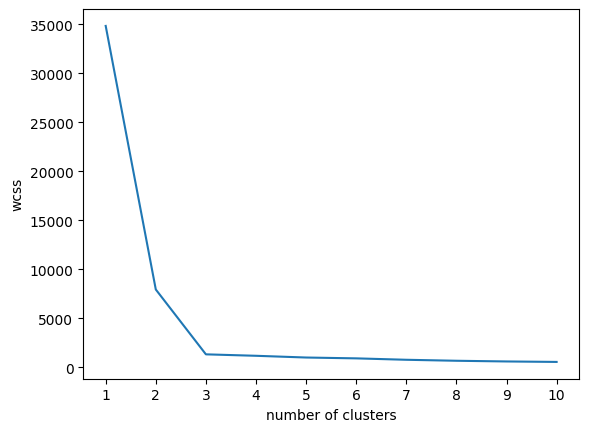

In [9]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("number of clusters")
plt.ylabel("wcss")
plt.show()


In [10]:
kmeans = KMeans(n_clusters=3,init="k-means++")

In [11]:
y_labels = kmeans.fit_predict(X_train)

In [12]:
y_test_label = kmeans.predict(X_test)

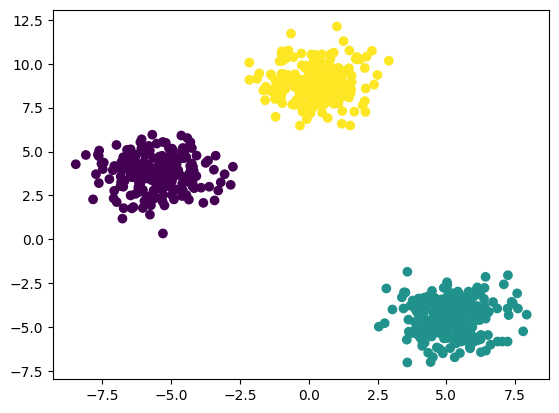

In [13]:
plt.scatter(X_train[:,0],X_train[:,1],c=y_labels)

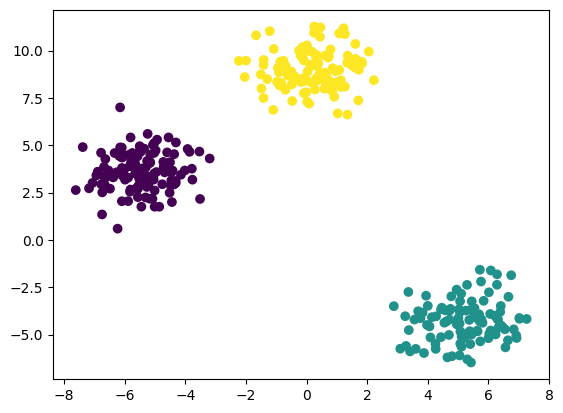

In [14]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_test_label)

In [15]:
!pip install kneed

In [16]:
from kneed import KneeLocator

In [17]:
kl = KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
print(kl.elbow)

3


In [18]:
from sklearn.metrics import silhouette_score

In [19]:
silhouette_coefficients = []
for k in range(2,11):
  kmeans = KMeans(n_clusters=k,init='k-means++')
  kmeans.fit(X_train)
  score=silhouette_score(X_train,kmeans.labels_)
  silhouette_coefficients.append(score)

In [20]:
silhouette_coefficients

[np.float64(0.7281443868598331),
 np.float64(0.8071181203797672),
 np.float64(0.6357733426488265),
 np.float64(0.48315998395814647),
 np.float64(0.5018002302013885),
 np.float64(0.46458986330484375),
 np.float64(0.3361349325328013),
 np.float64(0.33734111408406375),
 np.float64(0.33654074173336834)]

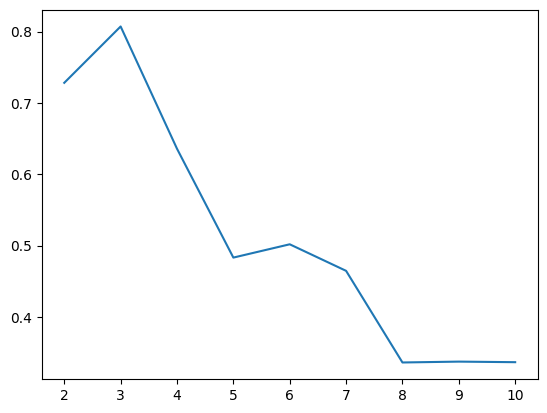

In [21]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.show()

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

In [23]:
iris = datasets.load_iris()

In [24]:
iris_data = pd.DataFrame(iris.data)

In [25]:
iris_data.columns = iris.feature_names

In [26]:
iris_data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [27]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [28]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.33,random_state=42)

In [29]:
x_scaled = scaler.fit_transform(X_train,X_test)

In [30]:
x_scaled

array([[ 1.1341297 , -1.18393903],
       [ 1.5892936 , -1.50932599],
       [ 1.21878338, -1.23008507],
       ...,
       [ 0.54869523, -1.35900014],
       [-1.12082946, -0.02850873],
       [ 0.93424501, -1.29388015]])

In [31]:
from sklearn.decomposition import PCA

In [32]:
pca = PCA(n_components=2)

In [33]:
pca_scaled= pca.fit_transform(x_scaled)

In [34]:
pca_scaled.shape

(670, 2)

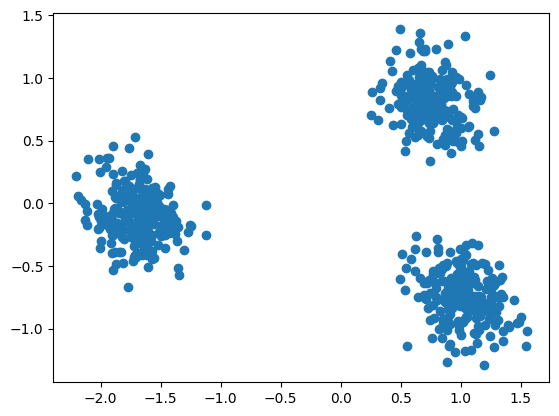

In [35]:
plt.scatter(pca_scaled[:,0],pca_scaled[:,1])

Text(0, 0.5, 'elu distance')

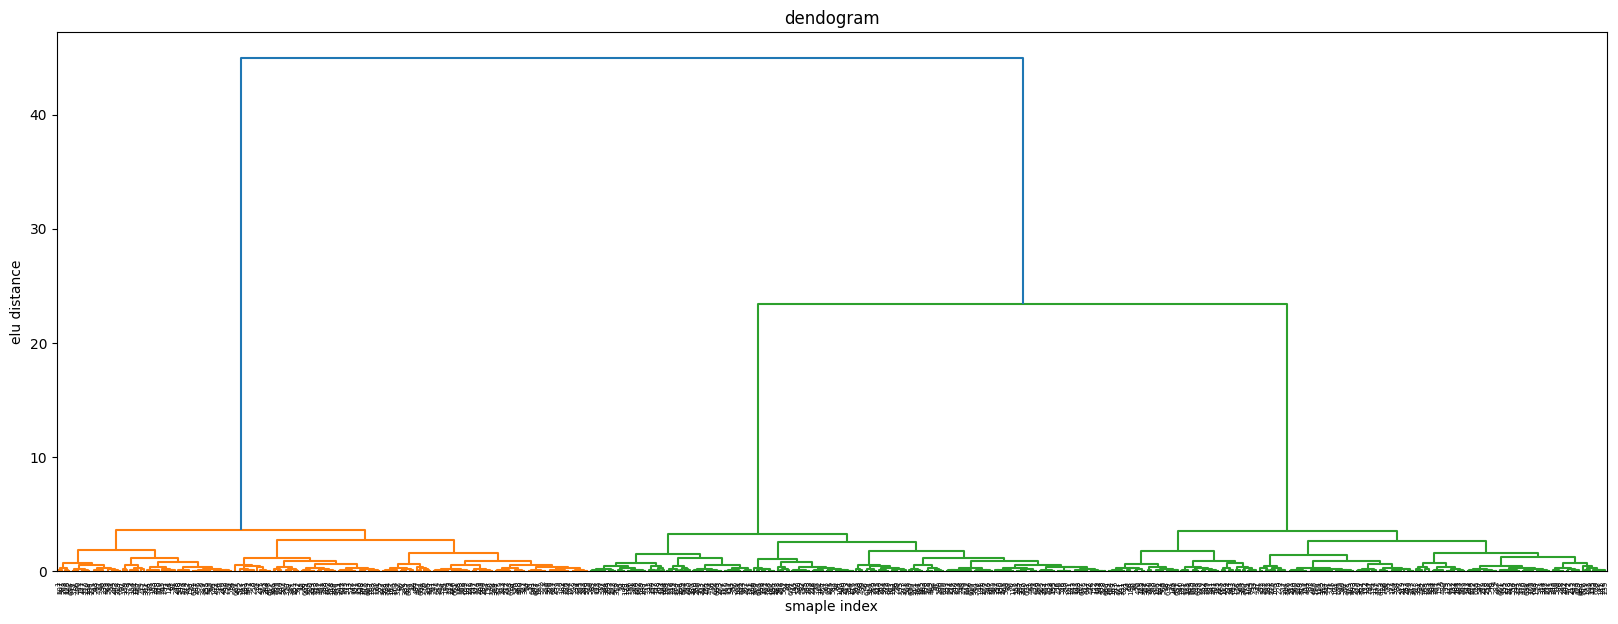

In [38]:
import scipy.cluster.hierarchy as sc

plt.figure(figsize=(20,7))
plt.title("dendogram")

sc.dendrogram(sc.linkage(pca_scaled,method='ward'))
plt.title('dendogram')
plt.xlabel('smaple index')
plt.ylabel('elu distance')